In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install supervision ultralytics trackers

from pathlib import Path
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import supervision as sv
from pathlib import Path
from ultralytics.models.sam import SAM3VideoSemanticPredictor
from ultralytics.models.sam import SAM3SemanticPredictor
import torch


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.6/273.6 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 15.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
ASSETS_BASE = "https://futbot-eight.vercel.app/assets"
ASSETS = ["futbot-01.jpg", "futbot-2s.mp4"]

Path("assets").mkdir(exist_ok=True)
for name in ASSETS:
    dest = Path("assets") / name
    if dest.exists() and dest.stat().st_size > 0:
        print(f"✓ {name} ya está en local")
    else:
        print(f"↓ descargando {name}...")
        urllib.request.urlretrieve(f"{ASSETS_BASE}/{name}", dest)
        print(f"  guardado en {dest}")

↓ descargando futbot-01.jpg...
  guardado en assets/futbot-01.jpg
↓ descargando futbot-2s.mp4...
  guardado en assets/futbot-2s.mp4


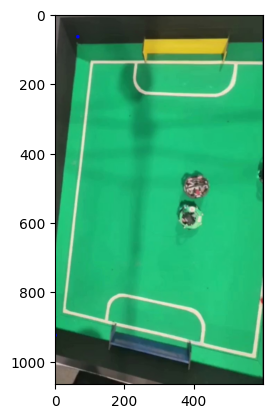

Imagen: 600×1066 px | H: (3, 3)


In [ ]:

image_bgr = cv2.imread("/content/drive/MyDrive/futbot/frame_300.jpg")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_rgb_2 = image_rgb.copy()

SOURCE_POINTS = [[65, 65], [600, 75], [600, 1080], [0, 925]]
cv2.circle(image_rgb_2,tuple(SOURCE_POINTS[0]),radius=5,color=(0,0,255),thickness=-20)
cv2.circle(image_rgb_2,tuple(SOURCE_POINTS[1]),radius=5,color=(0,0,255),thickness=-10)
cv2.circle(image_rgb_2,tuple(SOURCE_POINTS[2]),radius=5,color=(0,0,255),thickness=-10)
cv2.circle(image_rgb_2,tuple(SOURCE_POINTS[3]),radius=5,color=(0,0,255),thickness=-10)
plt.imshow(image_rgb_2)
plt.show()
SOURCE_POINTS = np.float32(SOURCE_POINTS)
CAMPO_W, CAMPO_H = 600, 1080 #width=600, height=1080
ESCALA_PX_CM = 2.0  # 1 cm real = 2 px en el campo canónico
TARGET_POINTS = np.float32([[0, 0], [CAMPO_W, 0], [CAMPO_W, CAMPO_H], [0, CAMPO_H]])

H = cv2.getPerspectiveTransform(SOURCE_POINTS, TARGET_POINTS)
CLASS_NAMES = {0: "team_1", 1: "team_2",2: "porteria_1",3: "porteria_2",4:"pelota"}
COLORS_HEX  = {0: "#00b4d8", 1: "#EBC72C", 2: "#ff5d1e",3: "#27F546",4:"#E027F5"}
COLORS_BGR  = {0: (216, 180, 0), 1: (60, 35, 239), 2: (0, 149, 255),3: (224, 39, 245),4: (245, 39, 60)}

print(f"Imagen: {image_bgr.shape[1]}×{image_bgr.shape[0]} px | H: {H.shape}")

In [ ]:
def project_mask_contour(mask: np.ndarray, H: np.ndarray) -> np.ndarray | None:
    """Proyecta el contorno exterior de una máscara al campo canónico."""
    contours, _ = cv2.findContours(mask.astype(np.uint8),
                                   cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    cnt = max(contours, key=cv2.contourArea)
    pts = cnt.reshape(-1, 1, 2).astype(np.float32)
    pts_proj = cv2.perspectiveTransform(pts, H)
    return pts_proj.reshape(-1, 2).astype(np.int32)

def draw_tactical_with_masks(dets_sam, class_ids, H: np.ndarray, campo_w: int = CAMPO_W, campo_h: int = CAMPO_H) -> np.ndarray:
    """Dibuja el mapa táctico simulando una cancha de fútbol robótico y proyecta las máscaras."""

    # Dibujar cancha
    canvas = np.zeros((campo_h, campo_w, 3), dtype=np.uint8)
    canvas[:] = (160, 51, 0)
    center_x, center_y = campo_w // 2, campo_h // 2

    try:
        logo = cv2.imread('/content/drive/MyDrive/futbot/borrego.png', cv2.IMREAD_UNCHANGED)
        if logo is not None:
            logo_size = int(campo_w * 0.5)
            logo_resized = cv2.resize(logo, (logo_size, logo_size))

            # Definir las coordenadas del ROI
            y1 = center_y - logo_size // 2
            y2 = y1 + logo_size
            x1 = center_x - logo_size // 2
            x2 = x1 + logo_size

            if logo_resized.shape[2] == 4:
                alpha_s = logo_resized[:, :, 3] / 255.0
                alpha_l = 1.0 - alpha_s

                for c in range(0, 3):
                    canvas[y1:y2, x1:x2, c] = (alpha_s * logo_resized[:, :, c] +
                                               alpha_l * canvas[y1:y2, x1:x2, c])
            else:
                canvas[y1:y2, x1:x2] = logo_resized[:,:,:3]
    except Exception as e:
        print(f"Nota: No se pudo insertar el logo de fondo. Detalle: {e}")

    # Dibujar lineas de la cancha
    line_color = (255, 255, 255)
    faint_color = (220, 220, 220)
    thickness = 4
    m = 30

    cv2.rectangle(canvas, (m, m), (campo_w - m, campo_h - m), line_color, thickness)
    cv2.circle(canvas, (center_x, center_y), int(campo_w * 0.22), faint_color, 2)

    # Parámetros para las áreas de portería
    gw = int(campo_w * 0.45)
    gd = int(campo_h * 0.12)
    r = 25

    def draw_u_shape_area(y_base, direction):
        x_left = center_x - gw // 2
        x_right = center_x + gw // 2
        pt_end_y = y_base + direction * (gd - r)

        cv2.line(canvas, (x_left, y_base), (x_left, pt_end_y), line_color, thickness)
        cv2.line(canvas, (x_right, y_base), (x_right, pt_end_y), line_color, thickness)

        y_horizontal = y_base + direction * gd
        cv2.line(canvas, (x_left + r, y_horizontal), (x_right - r, y_horizontal), line_color, thickness)

        if direction == 1:
            cv2.ellipse(canvas, (x_left + r, pt_end_y), (r, r), 0, 90, 180, line_color, thickness)
            cv2.ellipse(canvas, (x_right - r, pt_end_y), (r, r), 0, 0, 90, line_color, thickness)
        else:
            cv2.ellipse(canvas, (x_left + r, pt_end_y), (r, r), 0, 180, 270, line_color, thickness)
            cv2.ellipse(canvas, (x_right - r, pt_end_y), (r, r), 0, 270, 360, line_color, thickness)

    draw_u_shape_area(m, 1)
    draw_u_shape_area(campo_h - m, -1)

    for det_sam,class_id in zip(dets_sam,class_ids):
      masks     = det_sam.mask
      class_id_list = [class_id]*len(det_sam)

      if masks is not None:
          for m, cid in zip(masks, class_id_list):
              color = COLORS_BGR.get(int(cid), (200, 200, 200))

              # Relleno semitransparente
              m_uint8  = m.astype(np.uint8) * 255
              m_warped = cv2.warpPerspective(m_uint8, H, (campo_w, campo_h))
              overlay  = canvas.copy()
              overlay[m_warped > 0] = color
              canvas = cv2.addWeighted(overlay, 0.45, canvas, 0.55, 0)

              # ontorno proyectado
              contorno = project_mask_contour(m, H)
              if contorno is not None and len(contorno) > 2:
                  cv2.polylines(canvas, [contorno], True, color, 2)

              ys, xs = np.where(m)
              if len(xs) > 0:
                  cx = int(xs.mean()); cy = int(ys.mean())
                  pt = np.float32([[[cx, cy]]])
                  proj = cv2.perspectiveTransform(pt, H)
                  px, py = int(proj[0][0][0]), int(proj[0][0][1])
                  if 0 <= px < campo_w and 0 <= py < campo_h:
                      cv2.circle(canvas, (px, py), 8, color, -1)
                      cv2.circle(canvas, (px, py), 8, (255, 255, 255), 1)

    return canvas

'\ntactical_bgr = draw_tactical_with_masks(dets_sam, H)\nplt.figure(figsize=(6, 8.0))\nplt.imshow(cv2.cvtColor(tactical_bgr, cv2.COLOR_BGR2RGB))\nplt.title("Mapa táctico con máscaras SAM proyectadas — relleno + contorno")\nplt.axis("off")\nplt.tight_layout()\nplt.show()'

In [ ]:
OUTPUT_VIDEO = "/content/drive/MyDrive/futbot/IMG_9933_sam_v3.mp4"
SOURCE_VIDEO = "/content/drive/MyDrive/futbot/output_resized.mp4"
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO)
print(SOURCE_VIDEO)
print(video_info)

/content/drive/MyDrive/futbot/output_resized.mp4
VideoInfo(width=600, height=1080, fps=24.0, total_frames=5018)


In [ ]:
def update_team_heatmaps(
    dets_sam,
    heatmaps,
    H: np.ndarray,
    campo_w: int = CAMPO_W,
    campo_h: int = CAMPO_H
) -> dict:
    masks = dets_sam.mask

    class_ids = (
        dets_sam.class_id
        if dets_sam.class_id is not None
        else np.zeros(len(dets_sam), dtype=int)
    )

    heatmaps_creation = {
        cid: hm.copy()
        for cid, hm in heatmaps.items()
    }

    if masks is not None:
        for m, cid in zip(masks, class_ids):
            cid = int(cid)

            if cid not in heatmaps_creation:
                continue

            m_warped = cv2.warpPerspective(
                m.astype(np.uint8) * 255,
                H,
                (campo_w, campo_h)
            )

            heatmaps_creation[cid] += m_warped.astype(np.float32)

    for cid in heatmaps_creation:
        mx = heatmaps_creation[cid].max()

        if mx > 0:
            heatmaps_creation[cid] /= mx

    return heatmaps_creation


In [ ]:
from ultralytics import YOLO
INPUT_VIDEO  = SOURCE_VIDEO
OUTPUT_VIDEO = OUTPUT_VIDEO
SAM_MODEL    = "/content/drive/MyDrive/futbot/sam3.pt"
CONF         = 0.20
Yolomodel = YOLO("yolov8s.pt")

direccion= "vertical"

_penalty_state = {
    "team1_one":  {"active": False, "start_frame": None},
    "team1_zero": {"active": False, "start_frame": None},
    "team2_one":  {"active": False, "start_frame": None},
    "team2_zero": {"active": False, "start_frame": None},
}

def _update_timer(state_key, condition, frame_idx, fps):

    st = _penalty_state[state_key]
    if condition:
        if not st["active"]:
            st["active"]      = True
            st["start_frame"] = frame_idx
    else:
        st["active"]      = False
        st["start_frame"] = None

def _timer_text(state_key, frame_idx, fps, duration=60):

    st = _penalty_state[state_key]
    if not st["active"]:
        return None
    elapsed_sec = (frame_idx - st["start_frame"]) / fps
    remaining   = duration - elapsed_sec
    if remaining <= 0:
        return "0:00"
    m = int(remaining) // 60
    s = int(remaining) % 60
    return f"{m}:{s:02d}"


def draw_penalty_timers(annotated, det_rob_team1, det_rob_team2, frame_idx, fps):
    n1 = len(det_rob_team1)
    n2 = len(det_rob_team2)

    # Update timers
    _update_timer("team1_one",  n1 == 1, frame_idx, fps)
    _update_timer("team1_zero", n1 == 0, frame_idx, fps)
    _update_timer("team2_one",  n2 == 1, frame_idx, fps)
    _update_timer("team2_zero", n2 == 0, frame_idx, fps)

    # labels
    entries = [
        ("team1_one",  "T1 -1 robot: ",  (0,   200, 255)),
        ("team1_zero", "T1 -2 robots: ", (0,   140, 255)),
        ("team2_one",  "T2 -1 robot: ",  (255, 180,   0)),
        ("team2_zero", "T2 -2 robots: ", (255, 100,   0)),
    ]

    x0      = 10
    y_start = 115
    row_h   = 32
    font    = cv2.FONT_HERSHEY_SIMPLEX
    scale   = 0.75
    thick   = 2
    shadow  = (0, 0, 0)

    row = 0
    for state_key, prefix, color in entries:

        if state_key.endswith("one") and len(det_rob_team1 if "team1" in state_key else det_rob_team2) >= 2:
            continue
        if state_key.endswith("zero") and len(det_rob_team1 if "team1" in state_key else det_rob_team2) >= 2:
            continue

        txt = _timer_text(state_key, frame_idx, fps)
        if txt is None:
            continue

        label = prefix + txt
        y     = y_start + row * row_h


        cv2.putText(annotated, label, (x0 + 1, y + 1),
                    font, scale, shadow, thick + 1, cv2.LINE_AA)

        cv2.putText(annotated, label, (x0, y),
                    font, scale, color, thick, cv2.LINE_AA)
        row += 1

def team_identifier(det_rob_raw, frame):
    team1 = []
    team2 =[]

    for i in range(len(det_rob_raw)):
        if det_rob_raw.mask is None:
            return [], []
            continue

        mask = det_rob_raw.mask[i]

        ys, xs = np.where(mask)
        if len(xs) == 0:
            continue

        ymin, ymax = ys.min(), ys.max()
        xmin, xmax = xs.min(), xs.max()

        crop = frame[ymin:ymax, xmin:xmax]
        mask_crop = mask[ymin:ymax, xmin:xmax]

        obj = cv2.bitwise_and(crop, crop, mask=mask_crop.astype(np.uint8))


        hsv = cv2.cvtColor(obj, cv2.COLOR_BGR2HSV)
        green_mask = cv2.inRange(hsv, np.array([47, 50, 87]), np.array([81, 255, 255]))


        green_pixels = cv2.countNonZero(green_mask)
        total_pixels = cv2.countNonZero(mask_crop.astype(np.uint8))
        green_ratio  = green_pixels / total_pixels if total_pixels > 0 else 0

        if green_ratio > 0.15:
            team1.append(det_rob_raw[i])
        else:
            team2.append(det_rob_raw[i])

    return team1, team2



def detect_ball(frame):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))

    # Iluminación normal
    mask = cv2.inRange(hsv, np.array([7, 100, 150]), np.array([18, 255, 255]))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    def score_contours(mask, min_circ=0.45):
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        results = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < 80 or area > 3000:
                continue
            perimeter = cv2.arcLength(cnt, True)
            if perimeter == 0:
                continue
            circularity = 4 * np.pi * area / (perimeter ** 2)
            if circularity < min_circ:
                continue
            x, y, w, h_box = cv2.boundingRect(cnt)
            if not (0.4 < w / h_box < 2.5):
                continue
            results.append((circularity, area, x, y, w, h_box))
        return results

    cands = score_contours(mask)

    if not cands:
        # Si la luz cambia por sombra o mas luz
        mask2 = cv2.inRange(hsv, np.array([5, 50, 100]), np.array([25, 255, 255]))
        mask2 = cv2.morphologyEx(mask2, cv2.MORPH_CLOSE, kernel)
        mask2 = cv2.morphologyEx(mask2, cv2.MORPH_OPEN, kernel)
        cands = score_contours(mask2, min_circ=0.55)

    if not cands:
        return sv.Detections.empty()

    # solo el mejor candidato
    def score(c):
        circ, area, x, y, w, h = c
        size_score = 1.0 - abs(np.log(area / 400)) * 0.3
        return circ * max(size_score, 0.3)

    circ, area, x, y, w, h = max(cands, key=score)

    return sv.Detections(
        xyxy=np.array([[x, y, x + w, y + h]], dtype=np.float32),
        class_id=np.array([2], dtype=int),
        confidence=np.array([1.0], dtype=float),
    )


def goalhorizontal(ball,treshold_team1,treshold_team2,frame,fps,counter,current_goal):
  if treshold_team1.mask is None or treshold_team2.mask is None:
    return counter, current_goal
  if len(treshold_team1) == 0 or len(treshold_team2) == 0:
    return counter, current_goal

  # Treshold team1
  mask = treshold_team1.mask[0]

  ys, xs = np.where(mask)

  # Treshold team2
  mask2 = treshold_team2.mask[0]

  yss, xss = np.where(mask2)

  # Ball
  if len(ball) == 0:
      return counter,current_goal

  boundingbox=ball.xyxy
  x1=boundingbox[0][0]
  y1=boundingbox[0][1]
  x2=boundingbox[0][2]
  y2=boundingbox[0][3]
  middle_x=(x2-x1)/2 +x1
  middle_y=(y2-y1)/2+y2
  center_ball=[middle_x/2,middle_y/2]


  all_xs_team1 = xs.flatten()
  all_ys_team1 = ys.flatten()
  all_xs_team2 = xss.flatten()
  all_ys_team2 = yss.flatten()


  while counter== 0:
    if not((x1<=np.max(all_xs_team1))or(x2>=np.min(all_xs_team2))):
      break
    elif not (np.any(center_ball[1] == all_ys_team2) or np.any(center_ball[1] == all_ys_team1)):
      break
    counter=counter+1
    current_goal=frame
    return counter,current_goal

  while counter >= 1:
    if not((x1<=np.max(all_xs_team1))or(x2>=np.min(all_xs_team2))):
      break
    elif not (np.any(center_ball[1] == all_ys_team2) or np.any(center_ball[1] == all_ys_team1)):
      break
    elif frame>= (current_goal+(fps*3)):
      counter=counter+1
      current_goal=frame
    else:
      break
    return counter,current_goal
  return counter, current_goal

def goalvertical(ball, treshold_team1, treshold_team2, frame, fps,
                 counter_team1, counter_team2, current_goal_team1, current_goal_team2):

    if treshold_team1.mask is None or treshold_team2.mask is None:
        return counter_team1, current_goal_team1, counter_team2, current_goal_team2
    if len(treshold_team1) == 0 or len(treshold_team2) == 0:
        return counter_team1, current_goal_team1, counter_team2, current_goal_team2
    if len(ball) == 0:
        return counter_team1, current_goal_team1, counter_team2, current_goal_team2


    mask1 = treshold_team1.mask[0]
    ys1, xs1 = np.where(mask1)
    mask2 = treshold_team2.mask[0]
    ys2, xs2 = np.where(mask2)
    x1, y1, x2, y2 = ball.xyxy[0]
    cx = (x1 + x2) / 2

    # posiciones
    goal1_xmin, goal1_xmax = xs1.min(), xs1.max()
    goal1_ymax             = ys1.max()
    goal2_xmin, goal2_xmax = xs2.min(), xs2.max()
    goal2_ymin             = ys2.min()

    # Team1
    if goal2_xmin <= cx <= goal2_xmax and y2 >= goal2_ymin:
        if counter_team1 == 0 or frame >= current_goal_team1 + fps * 3:
            counter_team1 += 1
            current_goal_team1 = frame

    # Team2
    if goal1_xmin <= cx <= goal1_xmax and y1 <= goal1_ymax:
        if counter_team2 == 0 or frame >= current_goal_team2 + fps * 3:
            counter_team2 += 1
            current_goal_team2 = frame

    return counter_team1, current_goal_team1, counter_team2, current_goal_team2

    return counter_team1, current_goal_team1, counter_team2, current_goal_team2
def write(det_rob_team1, det_rob_team2,det_team1, det_team2,annotated,det_ball, frame_idx, total_frames,writer,counter_team1,counter_team2,fps):

  box_ann   = sv.BoxAnnotator(thickness=2)
  label_ann = sv.LabelAnnotator(text_scale=0.6, text_thickness=1)
  mask_ann  = sv.MaskAnnotator(opacity=0.40)




  if len(det_rob_team1) > 0 and det_rob_team1.mask is not None:
            annotated = mask_ann.annotate(scene=annotated, detections=det_rob_team1)
            annotated = box_ann.annotate(scene=annotated, detections=det_rob_team1)
            annotated = label_ann.annotate(scene=annotated, detections=det_rob_team1,
                                           labels=[f"Team_1 #{tid}" for tid in det_rob_team1.tracker_id])
  if len(det_rob_team2) > 0 and det_rob_team2.mask is not None:
            annotated = mask_ann.annotate(scene=annotated, detections=det_rob_team2)
            annotated = box_ann.annotate(scene=annotated, detections=det_rob_team2)
            annotated = label_ann.annotate(scene=annotated, detections=det_rob_team2,
                                           labels=[f"Team_2 #{tid}" for tid in det_rob_team2.tracker_id])


  if len(det_ball) > 0:
    annotated = box_ann.annotate(scene=annotated, detections=det_ball)
    annotated = label_ann.annotate(scene=annotated, detections=det_ball,
                                   labels=["ball"] * len(det_ball))

  if len(det_team1) > 0 and det_team1.mask is not None:
        annotated = mask_ann.annotate(scene=annotated, detections=det_team1)
        annotated = box_ann.annotate(scene=annotated, detections=det_team1)
        annotated = label_ann.annotate(scene=annotated, detections=det_team1,
                                           labels=[f"Team_1_Porteria #{tid}" for tid in det_team1.tracker_id])

  if len(det_team2) > 0 and det_team2.mask is not None:
        annotated = mask_ann.annotate(scene=annotated, detections=det_team2)
        annotated = box_ann.annotate(scene=annotated, detections=det_team2)
        annotated = label_ann.annotate(scene=annotated, detections=det_team2,
                                           labels=[f"Team_2_Porteria #{tid}" for tid in det_team2.tracker_id])

  cv2.putText(annotated, f"Goals Team1: {counter_team1}",
            (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2, cv2.LINE_AA)
  cv2.putText(annotated, f"Goals Team2: {counter_team2}",
            (10, 80), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2, cv2.LINE_AA)

  draw_penalty_timers(annotated, det_rob_team1, det_rob_team2, frame_idx, fps)

  if frame_idx % 30 == 0:
            print(f"  [{frame_idx/max(total_frames,1)*100:5.1f}%] frame {frame_idx:4d} — robots: {len(det_rob_team1)+ len(det_rob_team2)}")




In [ ]:
global counter_team1, current_goal_team1,counter_team2, current_goal_team2,time

def callback_prompt(frame: np.ndarray,frame_idx: int,counter_team1, current_goal_team1,counter_team2, current_goal_team2,time):
  overrides = dict(conf=CONF, task="segment", mode="predict", model=SAM_MODEL, verbose=False)
  overrides.update(half=True, device="cuda", imgsz=644)
  predictor = SAM3SemanticPredictor(overrides=overrides)

  tracker_rob_team1  = sv.ByteTrack()
  tracker_rob_team2  = sv.ByteTrack()
  tracker_team1 = sv.ByteTrack()
  tracker_team2 = sv.ByteTrack()
  tracker_ball = sv.ByteTrack()

  # Vista cenital
  warped = cv2.warpPerspective(
      frame,
      H,
      (CAMPO_W, CAMPO_H)
  )

  cap          = cv2.VideoCapture(INPUT_VIDEO)
  fps          = cap.get(cv2.CAP_PROP_FPS) or 30
  total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

  annotated = warped.copy()
  predictor.set_image(warped)
  try:
      det_rob_raw       = sv.Detections.from_ultralytics(predictor(text=["black circular robot"])[0])
      treshold_team1 = sv.Detections.from_ultralytics(predictor(text=["yellow rectangle"])[0])
      treshold_team2 = sv.Detections.from_ultralytics(predictor(text=["blue rectangle"])[0])
      ball           = detect_ball(warped)
  except Exception as e:
      print(f"[frame {frame_idx}] SAM error: {e}")
      team1_list, team2_list = [], []
      treshold_team1 = sv.Detections.empty()
      treshold_team2 = sv.Detections.empty()
      ball           = sv.Detections.empty()
  team1_list, team2_list = team_identifier(det_rob_raw, warped)

  team1 = sv.Detections.merge(team1_list) if team1_list else sv.Detections.empty()
  team2 = sv.Detections.merge(team2_list) if team2_list else sv.Detections.empty()

  det_rob_team1 = tracker_rob_team1.update_with_detections(team1)
  det_rob_team2 = tracker_rob_team2.update_with_detections(team2)
  det_team1 = tracker_team1.update_with_detections(treshold_team1)
  det_team2 = tracker_team2.update_with_detections(treshold_team2)
  det_ball  = tracker_ball.update_with_detections(ball)
  det_sam_list = [det_rob_team1,det_rob_team2,det_team1,det_team2,det_ball]
  class_ids_list = [0,1,2,3,4]

  # Mapa
  tactical = draw_tactical_with_masks(
      det_sam_list,
      class_ids_list,
      H
  )
  direccion = "v"
  if direccion == "v":
      counter_team1, current_goal_team1, counter_team2, current_goal_team2 = goalvertical(
                          ball=det_ball, treshold_team1=det_team1, treshold_team2=det_team2,
                          frame=frame_idx, fps=fps,
                          counter_team1=counter_team1, counter_team2=counter_team2,
                          current_goal_team1=current_goal_team1, current_goal_team2=current_goal_team2)
  elif direccion == "h":
      goal_counter,current_goal = goalhorizontal(ball=det_ball, treshold_team1=det_team1,
                                    treshold_team2=det_team2, frame=frame_idx,
                                    fps=fps, counter=goal_counter,
                                    current_goal=current_goal)

  write(det_rob_team1=det_rob_team1, det_rob_team2= det_rob_team2, det_team1=det_team1, det_team2=det_team2,
        annotated=annotated, det_ball=det_ball,
        frame_idx=frame_idx, total_frames=total_frames, writer=None, fps=fps, counter_team1=counter_team1, counter_team2=counter_team2)
  output = np.hstack([
      frame,
      annotated,
      tactical
  ])
  valores = (counter_team1, current_goal_team1,counter_team2, current_goal_team2,time)
  return output,valores

In [ ]:
from tqdm import tqdm

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO)

escala = CAMPO_H / video_info.height
orig_w = int(video_info.width * escala)

# Paneles:
# 1. original redimensionado
# 2. vista cenital
# 3. mapa táctico
# 4. heatmap equipo 0
# 5. heatmap equipo 1
# 6. heatmap colisiones
custom_width = orig_w + CAMPO_W + CAMPO_W
custom_height = CAMPO_H

custom_video_info = sv.VideoInfo(
    width=custom_width,
    height=custom_height,
    fps=video_info.fps,
    total_frames=video_info.total_frames
)

print(custom_video_info)

frame_generator = sv.get_video_frames_generator(
    source_path=SOURCE_VIDEO
)


VideoInfo(width=1800, height=1080, fps=24.0, total_frames=5018)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

counter_team1_new  = 0
current_goal_team1_new  = 0
counter_team2_new  = 0
current_goal_team2_new  = 0
frame_idx     = 0
time_new          = 60

with sv.VideoSink(
    target_path=OUTPUT_VIDEO,
    video_info=custom_video_info
) as sink:

    heatmaps = {
        0: np.zeros((CAMPO_H, CAMPO_W), dtype=np.float32),
        1: np.zeros((CAMPO_H, CAMPO_W), dtype=np.float32)
    }

    collision_heatmap = np.zeros(
        (CAMPO_H, CAMPO_W),
        dtype=np.float32
    )

    collisions_by_frame = {}

    for frame_idx, frame in enumerate(
        tqdm(
            frame_generator,
            total=custom_video_info.total_frames,
            desc="Procesando video"
        )
    ):

        processed_frame,valores = callback_prompt(
            frame=frame,
            frame_idx=frame_idx,
            counter_team1=counter_team1_new,
            current_goal_team1=current_goal_team1_new,
            counter_team2=counter_team2_new,
            current_goal_team2=current_goal_team2_new,
            time=time_new
        )

        counter_team1_new2, current_goal_team1_new2,counter_team2_new2, current_goal_team2_new2,time_new2 = valores
        print("/n")
        print(counter_team1_new2, current_goal_team1_new2,counter_team2_new2, current_goal_team2_new2,time_new2)
        counter_team1_new  = counter_team1_new2
        current_goal_team1_new  = current_goal_team1_new2
        counter_team2_new  = counter_team2_new2
        current_goal_team2_new  = current_goal_team2_new2
        time_new          = time_new2

        output_filename = "/content/drive/MyDrive/futbot/game_variables.txt"
        with open(output_filename, "a") as file:
          file.write(f"counter_team1 = {counter_team1_new}\n")
          file.write(f"current_goal_team1 = {current_goal_team1_new}\n")
          file.write(f"counter_team2 = {counter_team2_new}\n")
          file.write(f"current_goal_team2 = {current_goal_team2_new}\n")
          file.write(f"frame_idx = {frame_idx}\n")
          file.write(f"time = {time_new}\n")

        print(f"\nVariables successfully saved to {output_filename}")


        sink.write_frame(processed_frame)

print(f"✅ Video guardado: {OUTPUT_VIDEO}")


Procesando video:   0%|          | 0/5018 [00:00<?, ?it/s]

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...


Using Python 3.12.13 environment at: /usr
Resolved 37 packages in 521ms
Prepared 2 packages in 1.39s
Installed 2 packages in 0.84ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@577b3cfa75f072c20a3f02b44ffde111d93eb3be)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 2.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Results saved to /content/runs/segment/predict
Results saved to /content/runs/segment/predict
Results saved to /content/runs/segment/predict
  [  0.0%] frame    0 — robots: 3
/n
0 0 0 0 60


Procesando video:   0%|          | 1/5018 [01:08<95:11:20, 68.30s/it]


Variables successfully saved to /content/drive/MyDrive/futbot/game_variables.txt
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
Results saved to /content/runs/segment/predict-2
Results saved to /content/runs/segment/predict-2
Results saved to /content/runs/segment/predict-2


...

/n
0 0 1 156 60

Variables successfully saved to /content/drive/MyDrive/futbot/game_variables.txt
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
Results saved to /content/runs/segment/predict-207
Results saved to /content/runs/segment/predict-207
Results saved to /content/runs/segment/predict-207


Procesando video:   4%|▍         | 207/5018 [17:53<6:31:13,  4.88s/it]

/n
0 0 1 156 60

Variables successfully saved to /content/drive/MyDrive/futbot/game_variables.txt
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)


Procesando video:   4%|▍         | 207/5018 [17:57<6:57:24,  5.21s/it]


KeyboardInterrupt: 

In [ ]:
print(type(sink))

In [ ]:
print(SOURCE_VIDEO)

In [ ]:
PROMPT_1_COLLISION = "red ball"
PROMPT_2_COLLISION = "circular robot"
PROMPT_3_COLLISION = "green robot"

# Archivos de salida
OUTPUT_VIDEO_COLLISIONS = "/content/drive/MyDrive/futbot/BOGOBOTS_v3_with_collisions.mp4"
OUTPUT_TXT_COLLISIONS = "/content/drive/MyDrive/futbot/all_collision_coordinates.txt"

# Parámetros de colisión
TOLERANCE_PX_COLLISION = 2
MIN_CIRCULARITY_PROMPT_1 = 0.65
MIN_AREA_PROMPT_1 = 50
MAX_AREA_PROMPT_1 = None

MAX_FRAMES_COLLISION = None

In [ ]:
import math
import numpy as np
import cv2


def get_masks_from_sam_predictor(predictor, prompt_text):

    try:
        result = predictor(text=[prompt_text])[0]
        dets = sv.Detections.from_ultralytics(result)

        if dets.mask is None:
            return []

        return [m.astype(bool) for m in dets.mask]

    except Exception as e:
        print(f"Error con prompt '{prompt_text}': {e}")
        return []


def mask_circularity(mask):

    mask_uint8 = mask.astype(np.uint8)

    contours, _ = cv2.findContours(
        mask_uint8,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return 0.0, 0.0

    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    if perimeter == 0:
        return 0.0, area

    circularity = 4 * math.pi * area / (perimeter ** 2)

    return circularity, area


def filter_masks_by_circularity(
    masks,
    min_circularity=0.65,
    min_area=50,
    max_area=None
):

    filtered_masks = []
    stats = []

    for i, mask in enumerate(masks):
        circularity, area = mask_circularity(mask)

        valid = True

        if circularity < min_circularity:
            valid = False

        if area < min_area:
            valid = False

        if max_area is not None and area > max_area:
            valid = False

        stats.append({
            "mask_index": i,
            "circularity": circularity,
            "area": area,
            "valid": valid
        })

        if valid:
            filtered_masks.append(mask)

    return filtered_masks, stats


def resize_mask_to(mask, target_shape):

    if mask.shape[:2] == target_shape:
        return mask.astype(bool)

    resized = cv2.resize(
        mask.astype(np.uint8),
        (target_shape[1], target_shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    return resized.astype(bool)


def get_mask_border(mask):

    mask_uint8 = mask.astype(np.uint8)

    kernel = np.ones((3, 3), np.uint8)
    eroded = cv2.erode(mask_uint8, kernel, iterations=1)

    border = mask_uint8 - eroded

    return border.astype(bool)


def different_masks_touch_with_coordinates(
    mask_a,
    mask_b,
    tolerance_px=2,
    count_overlap=True,
    max_points_to_save=30
):

    mask_a = mask_a.astype(bool)
    mask_b = resize_mask_to(mask_b, mask_a.shape[:2])

    contact_map = None
    reason = None

    # Caso 1: las máscaras se traslapan
    if count_overlap:
        overlap = mask_a & mask_b

        if np.any(overlap):
            contact_map = overlap
            reason = "overlap"

    # Caso 2: los bordes se tocan o están cerca
    if contact_map is None:
        border_a = get_mask_border(mask_a)
        border_b = get_mask_border(mask_b)

        kernel_size = 2 * tolerance_px + 1
        kernel = np.ones((kernel_size, kernel_size), np.uint8)

        border_a_dilated = cv2.dilate(
            border_a.astype(np.uint8),
            kernel,
            iterations=1
        ).astype(bool)

        border_b_dilated = cv2.dilate(
            border_b.astype(np.uint8),
            kernel,
            iterations=1
        ).astype(bool)

        contact_map = (border_a_dilated & border_b) | (border_b_dilated & border_a)

        if np.any(contact_map):
            reason = "border_touch"

    if contact_map is None or not np.any(contact_map):
        return False, None, None, [], 0

    ys, xs = np.where(contact_map)

    contact_points = list(zip(xs.tolist(), ys.tolist()))
    num_contact_points = len(contact_points)

    center_x = int(np.mean(xs))
    center_y = int(np.mean(ys))
    contact_center = (center_x, center_y)

    if len(contact_points) > max_points_to_save:
        step = max(1, len(contact_points) // max_points_to_save)
        sampled_points = contact_points[::step][:max_points_to_save]
    else:
        sampled_points = contact_points

    return True, reason, contact_center, sampled_points, num_contact_points


def check_collision_between_mask_lists(
    masks_prompt_1,
    masks_prompt_2,
    frame_index,
    tolerance_px=2,
    min_circularity_prompt_1=0.65,
    min_area_prompt_1=50,
    max_area_prompt_1=None,
    count_overlap=True,
    max_points_to_save=30
):

    masks_1_filtered, stats_1 = filter_masks_by_circularity(
        masks_prompt_1,
        min_circularity=min_circularity_prompt_1,
        min_area=min_area_prompt_1,
        max_area=max_area_prompt_1
    )

    collisions = []

    for i, mask_1 in enumerate(masks_1_filtered):
        for j, mask_2 in enumerate(masks_prompt_2):

            touch, reason, contact_center, sampled_points, num_contact_points = different_masks_touch_with_coordinates(
                mask_a=mask_1,
                mask_b=mask_2,
                tolerance_px=tolerance_px,
                count_overlap=count_overlap,
                max_points_to_save=max_points_to_save
            )

            if touch:
                collisions.append({
                    "frame": frame_index,
                    "prompt_1_filtered_mask": i,
                    "prompt_2_mask": j,
                    "reason": reason,
                    "contact_center": contact_center,
                    "contact_points": sampled_points,
                    "num_contact_points": num_contact_points
                })

    return collisions

In [ ]:
def draw_collision_text_on_frame(
    frame,
    collisions_1_2,
    collisions_1_3,
    prompt_1,
    prompt_2,
    prompt_3
):
    """
    Dibuja información de colisiones sobre el frame final.
    """
    output = frame.copy()

    y = 45

    cv2.putText(
        output,
        f"Colisiones {prompt_1} vs {prompt_2}: {len(collisions_1_2)}",
        (30, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2,
        cv2.LINE_AA
    )

    y += 35

    cv2.putText(
        output,
        f"Colisiones {prompt_1} vs {prompt_3}: {len(collisions_1_3)}",
        (30, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2,
        cv2.LINE_AA
    )

    y += 45

    if len(collisions_1_2) > 0 or len(collisions_1_3) > 0:
        cv2.putText(
            output,
            "COLISION DETECTADA",
            (30, y),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (0, 0, 255),
            3,
            cv2.LINE_AA
        )

    return output


def save_all_collision_coordinates_txt(
    collisions_by_frame_1_2,
    collisions_by_frame_1_3,
    prompt_1,
    prompt_2,
    prompt_3,
    output_txt_path="all_collision_coordinates.txt"
):
    """
    Guarda todas las coordenadas de colisión en un TXT.
    """
    with open(output_txt_path, "w", encoding="utf-8") as f:
        f.write("REPORTE DE COLISIONES\n")
        f.write("=====================\n\n")

        f.write(f"Prompt 1: {prompt_1}\n")
        f.write(f"Prompt 2: {prompt_2}\n")
        f.write(f"Prompt 3: {prompt_3}\n\n")

        f.write("Formato de coordenadas: (x, y)\n")
        f.write("x = posicion horizontal en pixeles\n")
        f.write("y = posicion vertical en pixeles\n\n")

        f.write("COLISIONES PROMPT 1 VS PROMPT 2\n")
        f.write("--------------------------------\n")

        if len(collisions_by_frame_1_2) == 0:
            f.write("No se detectaron colisiones.\n\n")
        else:
            for frame_index in sorted(collisions_by_frame_1_2.keys()):
                collisions = collisions_by_frame_1_2[frame_index]

                f.write(f"\nFrame {frame_index}\n")

                for i, c in enumerate(collisions):
                    f.write(f"  Colision {i + 1}\n")
                    f.write(f"    {prompt_1} mask: {c.get('prompt_1_filtered_mask')}\n")
                    f.write(f"    {prompt_2} mask: {c.get('prompt_2_mask')}\n")
                    f.write(f"    Razon: {c.get('reason')}\n")
                    f.write(f"    Centro de contacto: {c.get('contact_center')}\n")
                    f.write(f"    Pixeles de contacto: {c.get('num_contact_points')}\n")
                    f.write("    Coordenadas de contacto:\n")

                    for point in c.get("contact_points", []):
                        f.write(f"      {point}\n")

        f.write("\n\n")

        f.write("COLISIONES PROMPT 1 VS PROMPT 3\n")
        f.write("--------------------------------\n")

        if len(collisions_by_frame_1_3) == 0:
            f.write("No se detectaron colisiones.\n\n")
        else:
            for frame_index in sorted(collisions_by_frame_1_3.keys()):
                collisions = collisions_by_frame_1_3[frame_index]

                f.write(f"\nFrame {frame_index}\n")

                for i, c in enumerate(collisions):
                    f.write(f"  Colision {i + 1}\n")
                    f.write(f"    {prompt_1} mask: {c.get('prompt_1_filtered_mask')}\n")
                    f.write(f"    {prompt_3} mask: {c.get('prompt_2_mask')}\n")
                    f.write(f"    Razon: {c.get('reason')}\n")
                    f.write(f"    Centro de contacto: {c.get('contact_center')}\n")
                    f.write(f"    Pixeles de contacto: {c.get('num_contact_points')}\n")
                    f.write("    Coordenadas de contacto:\n")

                    for point in c.get("contact_points", []):
                        f.write(f"      {point}\n")

    print("TXT guardado en:", output_txt_path)
    return output_txt_path

In [ ]:
from tqdm import tqdm

video_info_collision = sv.VideoInfo.from_video_path(SOURCE_VIDEO)
escala_collision = CAMPO_H / video_info_collision.height
orig_w_collision = int(video_info_collision.width * escala_collision)

custom_video_info_collision = sv.VideoInfo(
    width=orig_w_collision + CAMPO_W + CAMPO_W,
    height=CAMPO_H,
    fps=video_info_collision.fps,
    total_frames=video_info_collision.total_frames
)

# Generador de frames
frame_generator_collision = sv.get_video_frames_generator(
    source_path=SOURCE_VIDEO
)

overrides_collision = dict(
    conf=CONF,
    task="segment",
    mode="predict",
    model=SAM_MODEL,
    verbose=False
)

overrides_collision.update(
    half=True,
    device="cuda",
    imgsz=644
)

predictor_collision = SAM3SemanticPredictor(
    overrides=overrides_collision
)

# Diccionarios
collisions_by_frame_1_2_added = {}
collisions_by_frame_1_3_added = {}

# Variables del juego
counter_team1_new = 0
current_goal_team1_new = 0
counter_team2_new = 0
current_goal_team2_new = 0
time_new = 60

with sv.VideoSink(
    target_path=OUTPUT_VIDEO_COLLISIONS,
    video_info=custom_video_info_collision
) as sink:

    for frame_idx, frame in enumerate(
        tqdm(
            frame_generator_collision,
            total=custom_video_info_collision.total_frames,
            desc="Procesando video con colisiones"
        )
    ):

        if MAX_FRAMES_COLLISION is not None and frame_idx >= MAX_FRAMES_COLLISION:
            break

        warped_collision = cv2.warpPerspective(
            frame,
            H,
            (CAMPO_W, CAMPO_H)
        )

        predictor_collision.set_image(warped_collision)

        masks_prompt_1 = get_masks_from_sam_predictor(
            predictor_collision,
            PROMPT_1_COLLISION
        )

        masks_prompt_2 = get_masks_from_sam_predictor(
            predictor_collision,
            PROMPT_2_COLLISION
        )

        masks_prompt_3 = get_masks_from_sam_predictor(
            predictor_collision,
            PROMPT_3_COLLISION
        )

        collisions_1_2 = check_collision_between_mask_lists(
            masks_prompt_1=masks_prompt_1,
            masks_prompt_2=masks_prompt_2,
            frame_index=frame_idx,
            tolerance_px=TOLERANCE_PX_COLLISION,
            min_circularity_prompt_1=MIN_CIRCULARITY_PROMPT_1,
            min_area_prompt_1=MIN_AREA_PROMPT_1,
            max_area_prompt_1=MAX_AREA_PROMPT_1,
            count_overlap=True,
            max_points_to_save=30
        )

        collisions_1_3 = check_collision_between_mask_lists(
            masks_prompt_1=masks_prompt_1,
            masks_prompt_2=masks_prompt_3,
            frame_index=frame_idx,
            tolerance_px=TOLERANCE_PX_COLLISION,
            min_circularity_prompt_1=MIN_CIRCULARITY_PROMPT_1,
            min_area_prompt_1=MIN_AREA_PROMPT_1,
            max_area_prompt_1=MAX_AREA_PROMPT_1,
            count_overlap=True,
            max_points_to_save=30
        )

        if len(collisions_1_2) > 0:
            collisions_by_frame_1_2_added[frame_idx] = collisions_1_2

        if len(collisions_1_3) > 0:
            collisions_by_frame_1_3_added[frame_idx] = collisions_1_3

        processed_frame, valores = callback_prompt(
            frame=frame,
            frame_idx=frame_idx,
            counter_team1=counter_team1_new,
            current_goal_team1=current_goal_team1_new,
            counter_team2=counter_team2_new,
            current_goal_team2=current_goal_team2_new,
            time=time_new
        )

        counter_team1_new, current_goal_team1_new, counter_team2_new, current_goal_team2_new, time_new = valores

        processed_frame = draw_collision_text_on_frame(
            frame=processed_frame,
            collisions_1_2=collisions_1_2,
            collisions_1_3=collisions_1_3,
            prompt_1=PROMPT_1_COLLISION,
            prompt_2=PROMPT_2_COLLISION,
            prompt_3=PROMPT_3_COLLISION
        )

        sink.write_frame(processed_frame)

print("Video con colisiones guardado en:", OUTPUT_VIDEO_COLLISIONS)
print("Frames con colisión prompt 1 vs prompt 2:", len(collisions_by_frame_1_2_added))
print("Frames con colisión prompt 1 vs prompt 3:", len(collisions_by_frame_1_3_added))

In [ ]:
txt_all_collisions = save_all_collision_coordinates_txt(
    collisions_by_frame_1_2=collisions_by_frame_1_2_added,
    collisions_by_frame_1_3=collisions_by_frame_1_3_added,
    prompt_1=PROMPT_1_COLLISION,
    prompt_2=PROMPT_2_COLLISION,
    prompt_3=PROMPT_3_COLLISION,
    output_txt_path=OUTPUT_TXT_COLLISIONS
)

print("Archivo TXT final:", txt_all_collisions)